# CLT and Confidence Interval

In [1]:
import numpy as np
import scipy as sp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=110)

## 1 Central Limit Theorem

### 1.1 Sampling Distribution

#### Definition

A sampling distribution is the probability distribution of a statistic (like the mean or proportion) calculated from all possible random samples of a fixed size taken from a given population.

#### Sampling Distribution of Mean

Distribution of sample means. Probability distribution of means calculated from random samples of a fixed size taken from the population.

#### How to form a Sampling Distribution of mean?

**STEP #1**: Draw $m$ number of random samples of size $n$ from a population.  
**STEP #2**: Calculate mean for each sample a.k.a sample mean $\bar{x}$.   
**STEP #3**: Collect all sample means from STEP #2.  
**STEP #4**: Plot the collected means, collection of these sample means forms a **Sampling Distribution**.

Given a random variable $X$

$$
\large
\begin{aligned}
X_1 & = [x_1,\,x_2,\,x_3,\,\ldots,\,x_n] \rightarrow \bar{X}_1 \\[5pt]
X_2 & = [x_1,\,x_2,\,x_3,\,\ldots,\,x_n] \rightarrow \bar{X}_2 \\
    & \vdots                                                   \\
X_m & = [x_1,\,x_2,\,x_3,\,\ldots,\,x_n] \rightarrow \bar{X}_m \\[12pt]
\text{Collection of}&\;\text{Sample Means}\;\bar{X}:\{\bar{X}_1,\,\bar{X}_2,\,\ldots,\,\bar{X}_m\}
\end{aligned}
$$

Where,

- $X_1: [x_1,\,\ldots,\,x_n]$ - Sample #1 of size $n$ drawn from $X$
- $\{X_1,\,\ldots,\,X_m\}$ - $m$ number of samples of size $n$ drawn from $X$
- $\bar{X}_1$ - Mean of Sample #1
- $\{\bar{X}_1,\,\ldots,\,\bar{X}_m\}$ - $m$ number of means of samples drawn from $X$

> **Note**:
>
> 1. Mean Sampling distribution is a **distribution of means** and not original dataset.
> 2. Sampling distribution of mean has its **own mean**.

### 1.2 Central Limit Theorem

#### Theorem

- The distribution of sample means approximates a Normal Distribution regardless of the original shape of the distribution of underlying population.
- Mean of the sample means from Sampling Distribution will be approximately equal to population mean.

$$
\large
\begin{aligned}
\bar{X} \sim N\biggl(\mu\;, \frac{\sigma}{\sqrt{n}} \biggr)
\end{aligned}
$$

#### Properties of CLT

1. Population distribution may or may be normal but **sampling distribution is always a Normal Distribution**.
2. Mean of sampling distribution tends to become closer to the population mean with decently large sample size.
3. Closer the population distribution is towards the normal distribution, smaller can be the sample size.
4. As per CLT, parameter $m$ (total number of samples drawn from population) has **no significance**.
5. As we increase sample size standard deviation in sampling distribution decreases.
6. CLT is **not affected by the outliers**.

#### SE in CLT

1. Standard Error is actually the Standard Deviation of Sampling Distribution.
2. Since Standard Error is inversely proportional to Sample size, Larger the sample size smaller the Standard Error.

> **Note**:
>
> Thumb rule: $n \ge 30$. Typically sample size is suggested to be at least 30 or greater.

### 1.3 Conditions of CLT

#### Condition #1: Randomization

Data should be randomly sampled, ensuring every population member has an equal chance of being included.

#### Condition #2: Independence

1. Each sample value should be independent, with one event's occurrence not affecting another.
2. Commonly met in probability sampling methods, which independently select observations.

#### Condition #3: Large Sample Condition

1. A sample size of 30 or more is generally considered "sufficiently large."
2. This threshold can vary slightly based on the population distribution's shape.

## 2 Implement CLT

### 2.1 Setup

#### Population Dataset

In [2]:
df = pd.read_csv("data/weight-height.csv")

rows, cols = df.shape

display(df.head(3))
print(f"Dataset has {rows} rows and {cols} columns.")

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856


Dataset has 10000 rows and 3 columns.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


#### Population Parameters

In [4]:
rv_label = "Weight"  # Try other variables by replacing this value.
df[rv_label].describe().round(2).to_frame().T

,count,mean,std,min,25%,50%,75%,max
Weight,10000.0,161.44,32.11,64.7,135.82,161.21,187.17,269.99


##### Observations

1. Population mean: 161.44
2. Population Standard-deviation: 32.11

In [5]:
mu = 161.44
sigma = 32.11

### 2.2 Code

#### Sampling

In [6]:
def mean_sampling(data, rv, n=30, m=50):
    """
    Function to extract sample of size `n` from population `data` for given
    random variable `rv` and repeat the sampling process `m` number of times.

    Collect and return the sample means.
    """
    sample_means: list = []
    for _ in range(m):
        # Draw a sample of size `n` from population.
        sample = rng.choice(a=df[rv].values, size=n)

        # Calculate mean of the sample.
        sample_mean = np.mean(sample)

        # Collect mean of of all `m` samples.
        sample_means.append(sample_mean.item())

    # Return `m` sample-means.
    return sample_means

#### Plot Mean Sampling Distribution

In [7]:
def plot_mean_sampling_distribution(s_means, n):
    """
    Function to plot Mean Sampling Distribution for `s_means`.
    """
    plt.figure(figsize=(12, 4))

    # Plot histogram.
    plt.subplot(1, 2, 1)
    sns.histplot(x=s_means)
    plt.title(f"Histogram: Sample size {n}")
    plt.xlabel("Sample Means")
    plt.ylabel("Count")

    # Plot PDF distribution.
    plt.subplot(1, 2, 2)
    sns.kdeplot(x=s_means)
    plt.title(f"Probability Density Function: Sample size {n}")
    plt.xlabel("Sample Means")
    plt.ylabel("Probability Density")

    plt.show()

### 2.3 Empirical evaluation of CLT

#### 1 Sample size 3

Collect Sample Means

In [8]:
n = 3
s_means1 = mean_sampling(df, rv_label, n)
s_means1[:4]

[143.05778016247834, 166.79506537131033, 187.04999434417732, 158.751710817235]

In [9]:
print("Mean of Sample means:", np.mean(s_means1).round(2).item())

Mean of Sample means: 159.95


In [10]:
se1 = np.std(s_means1) / np.sqrt(n)
print("Standard Error:", se1.round(6).item())

Standard Error: 10.24432


Plot Mean Sampling Distribution

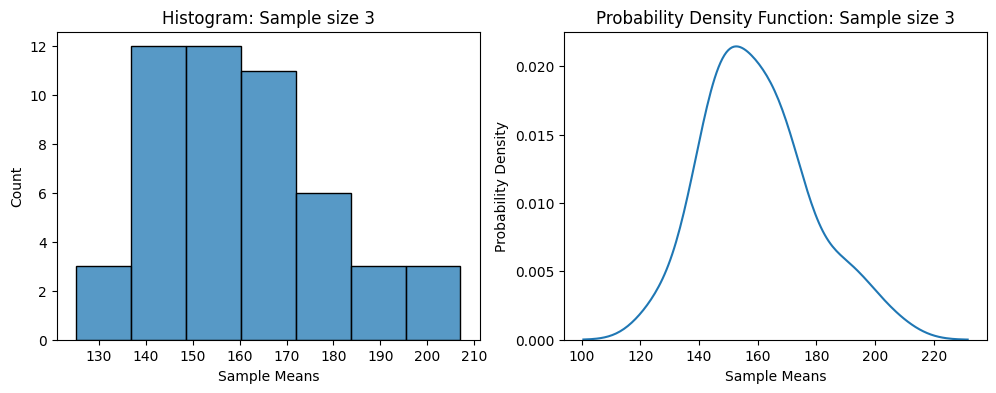

In [11]:
plot_mean_sampling_distribution(s_means1, n)

#### 2 Sample size 30

Collect Sample Means

In [12]:
n = 30
s_means2 = mean_sampling(df, rv_label, n)
s_means2[:4]

[164.13742370241548, 168.31182176474195, 162.5973703120224, 167.8535561166341]

In [13]:
print("Mean of Sample means:", np.mean(s_means2).round(2).item())

Mean of Sample means: 161.54


In [14]:
se2 = np.std(s_means2) / np.sqrt(n)
print("Standard Error:", se2.round(6).item())

Standard Error: 1.000623


Plot Mean Sampling Distribution

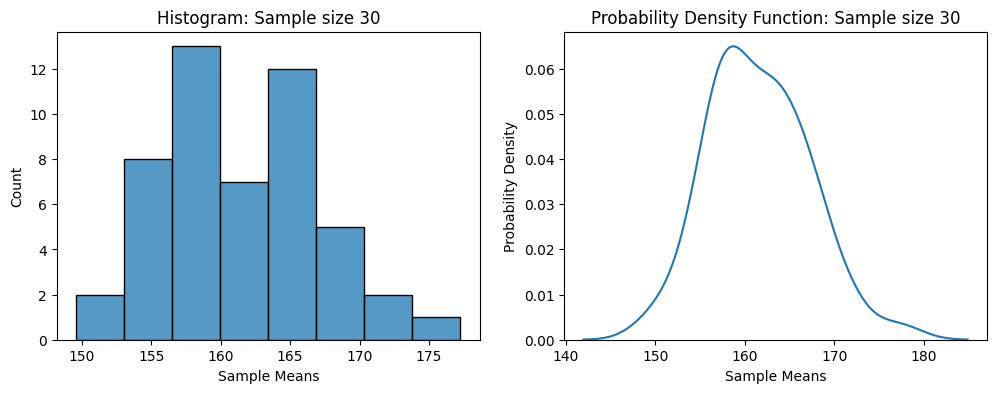

In [15]:
plot_mean_sampling_distribution(s_means2, n)

#### 3 Sample size 300

Collect Sample Means

In [16]:
n = 300
s_means3 = mean_sampling(df, rv_label, n)
s_means3[:4]

[164.22110380697796, 159.3642151293103, 164.66712008893427, 162.70395977866255]

In [17]:
print("Mean of Sample means:", np.mean(s_means3).round(2).item())

Mean of Sample means: 161.62


In [18]:
se3 = np.std(s_means3) / np.sqrt(n)
print("Standard Error:", se3.round(6).item())

Standard Error: 0.098769


Plot Mean Sampling Distribution

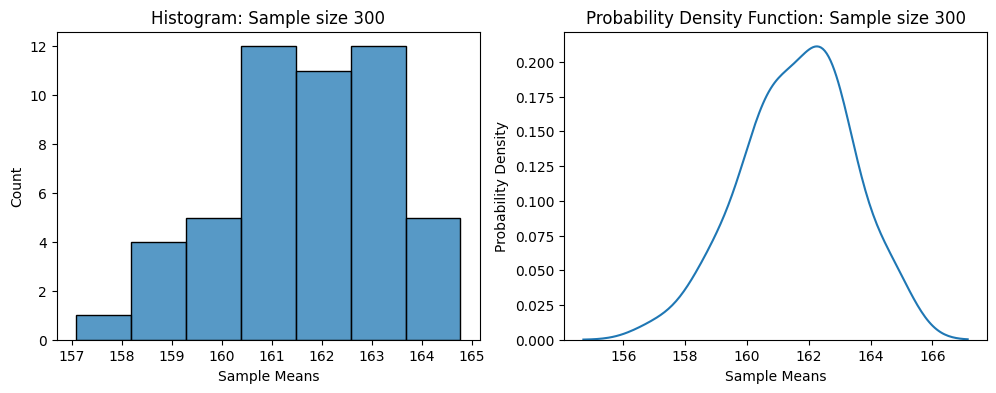

In [19]:
plot_mean_sampling_distribution(s_means3, n)

##### Observations

As sample size increase from 3 to 300:

1. The shape of the mean sampling distribution appears more like a Bell curve (Normal Distribution).
2. The mean of the sampling distribution tends to move closer to the population mean 161.44:
   1. Sample size: 3, Mean of sample distribution: 159.95
   2. Sample size: 30, Mean of sample distribution: 161.54
   3. Sample size: 300, Mean of sample distribution: 161.62
3. Sample Error reduces as sample size increases:
   1. Sample size: 3, Sample Error: 10.24432
   2. Sample size: 30, Sample Error: 1.000623
   3. Sample size: 300, Sample Error: 0.098769

### 2.4 Exercises

#### Exercise #1

Systolic blood pressure of a group of people is known to have an average of 122 mmHg and a standard deviation of 10 mmHg.  
Calculate the probability that the average blood pressure of 16 people will be greater than 125 mmHg.  

##### Solution

In [20]:
mu = 122  # Population Mean
sigma = 10  # Population standard-deviation
n = 16  # Sample size

# Find: P(X > 125)
#       P(X > 125) = 1 - P(X < 125)
x = 125

In [21]:
se = sigma / np.sqrt(n)  # Standard Error
se.round(6).item()

2.5

In [22]:
z_score = (x - mu) / se  # Z-Score
z_score.round(6).item()

1.2

In [23]:
p_x_gt_125 = 1 - sp.stats.norm.cdf(z_score)  # Probability of X > 125
p_x_gt_125.round(6).item()

0.11507

#### Exercise #2

In an e-commerce website, the average purchase amount per customer is 80 with a standard deviation of 15.  
If we randomly select a sample of 50 customers,  
what is the probability that the average purchase amount in the sample will be less than $75?

##### Solution

In [24]:
mu = 80  # Population Mean
sigma = 15  # Population standard-deviation
n = 50  # Sample size

# Find: P(X < 75)
x = 75

In [25]:
se = sigma / np.sqrt(n)  # Standard Error
se.round(6).item()

2.12132

In [26]:
z_score = (x - mu) / se  # Z-Score
z_score.round(6).item()

-2.357023

In [27]:
p_x_lt_75 = sp.stats.norm.cdf(z_score)
p_x_lt_75.round(6).item()

0.009211

## 3 Confidence Interval

In Statistics parameters of the population (such as mean, variance, etc.) are often estimated based on a Sample.

### 3.1 What is Confidence Interval?

#### Definition

A Confidence Interval is a **range of plausible values** suggested as **estimates** for an unknown population parameter, instead of a single value estimate (a.k.a point estimate).

#### Why to compute CI?

- Point Estimate is a single value and may be **inaccurate** and/or **biased**.
- Point Estimate (single value) have low confidence, instead intervals (range of values) have higher confidence.

#### How CI works?

1. CI estimates an interval/range such that population parameter falls in between that **range** with some **confidence score**.
2. For example with 95% confidence the population parameter can fall in between $[x_1, x_2]$.
3. CI has two components using which the rage is generated:
   1. Point Estimate
   2. Margin of Error

#### Formula

Formula to calculate Confidence Interval:

$$
\large
\begin{aligned}
\text{Confidence Interval} = \text{Point Estimate} \pm \text{Margin of Error}
\end{aligned}
$$

Where,

- $\text{Point Estimate}$ can be Sample mean, Sample proportion, Sample variance, etc.
- $\text{Margin of Error}$ is the maximum distance from the Point-Estimate to either endpoints of confidence interval.

#### How to compute CI?

There are two ways to find confidence interval:

1. Using CLT
2. Using Bootstrapping

### 3.2 Application of CLT in CI

#### How CLT is used in CI for Mean?

1. Sample mean is a Point Estimate of population mean hence it is not correct approach in estimating Population mean.
2. When sample mean is available use CLT to estimate population mean with some confidence interval.
3. As per CLT, **mean of sample means** is very close to population mean hence can be used as **Point-Estimate**.
4. **Standard deviation** of mean of sample means can be used as **Margin-of-Error**.

#### Formula

Formula to calculate Confidence Interval for population mean using Central Limit Theorem:

$$
\large
\begin{aligned}
\text{Confidence Interval} &= \biggl[\bar{X} \pm Z \cdot \frac{\sigma}{\sqrt{n}} \biggr] \\[10pt]
                           &= \biggl[\bar{X} - Z \cdot \frac{\sigma}{\sqrt{n}}\;\;,\quad\bar{X} + Z \cdot \frac{\sigma}{\sqrt{n}} \biggr]
\end{aligned}
$$

Where,

- $\bar{X}$ - Mean of the Sample means
- $Z$ - Z-Score
- $\displaystyle \frac{\sigma}{\sqrt{n}}$ - Standard Error

#### Properties

1. Using CLT we are estimating population mean between some interval with some confidence level.
2. Mean of sample means acts as Point Estimate.
3. Product of Z-score and Standard Error acts as Margin-of-Error.
4. Confidence interval provides a range within which the value of true mean (population mean) lies with high probability.

#### Steps to Calculate CI using CLT

1. Calculate point-estimate (say sample mean) using sample of size $n$.
2. Calculate standard-error.
1. Calculate Z-score for the given confidence interval using percent-point-function.
2. Calculate range by adding and subtracting product of Z-score and standard-error with point-estimate.

##### Approach #1

Two step process to compute Confidence Interval for population mean:

1. Find z-score for margin error.
2. Compute interval using margin of error.


```python
import numpy as np
import scipy as sp

n =            # Sample size
x_bar =        # Sample mean
s =            # Sample standard-deviation
confidence =   # Confidence level, example 95%

se = x_bar / np.sqrt(n)  # Standard error

alpha = 1 - confidence
# Two-sided Z-critical value.
z_score = sp.stats.norm.ppf(1 - alpha/2)

x1 = x_bar - (z_score * se)
x2 = x_bar + (z_score * se)
```

##### Approach #2

Directly compute confidence intervals without having to compute intermediate Z-score.

```python
import scipy as sp

n =            # Sample size
x_bar =        # Sample mean
s =            # Sample standard-deviation
confidence =   # Confidence level, example 95%

se = x_bar / np.sqrt(n)  # Standard error

x1, x2 = sp.stats.norm.interval(confidence, loc=x_bar, scale=se)
```

### 3.3 Application of Bootstrapping in CI

#### What is Bootstrapping?

Bootstrapping is the process of **sampling with replacement**.

#### When Bootstrapping is used?

Bootstrapping is used when the dataset is very small.

#### How Bootstrapping is used in CI?

- When we have median we use Bootstrapping to estimate population mean with some confidence interval.
- Bootstrapping is sampling **with replacement**.
- In Bootstrapping a **bootstrap sample** is drawn from the population.
- By convention Bootstrap sample is of same size as population (because population size itself is very small).

#### Properties

1. Bootstrapping can be used for estimating any population parameters like: Median, Percentiles, Standard-deviation etc.
2. **Not affected by outliers**.
3. This method is useful when we have very **small dataset**.

#### Steps to Calculate CI using Bootstrapping

- **STEP #1**: Draw **Bootstrap sample** from population dataset.
- **STEP #2**: Calculate required sample statistic (mean, median, SD, etc.) from Bootstrap sample.
- **STEP #3**: Collect the sample statistic computed in STEP #2.
- **STEP #4**: Repeat STEP #1 through STEP #3 $m$ number of time.

####  Implementation of Bootstrapping

In [28]:
def bootstrapping(data, get_sample_statistic, smpl_size=0, itrs=100):
    """
    Function to perform bootstrapping on population `data`.
    """
    # By default sample size will be same as population.
    smpl_size = smpl_size if smpl_size > 0 else len(data)

    smpl_stats = []
    for _ in range(itrs):
        # Bootstrap sample derived using sampling with replacement.
        bs_smpl = rng.choice(a=data, size=smpl_size, replace=True)

        # Compute and collect the required
        # sample-statistic from bootstrap-sample.
        smpl_stat = get_sample_statistic(bs_smpl)
        smpl_stats.append(smpl_stat)

    # Return collected sample statistics.
    return smpl_stats

#### Examples

##### Example #1

In [29]:
data = np.array([4, 1, 2, 2, 3, 1, 3, 3, 3, 4, 5, 5, 7, 7, 7, 7, 7, 7, 7, 9, 8, 8, 3, 8, 7])

display(data)
print("Size:", len(data))

array([4, 1, 2, 2, 3, 1, 3, 3, 3, 4, 5, 5, 7, 7, 7, 7, 7, 7, 7, 9, 8, 8, 3, 8, 7])

Size: 25


In [30]:
mu = np.mean(data)
sigma = np.std(data)

print("Population Mean:", mu)
print("Population Standard-deviation:", sigma.round(6))

Population Mean: 5.12
Population Standard-deviation: 2.4219


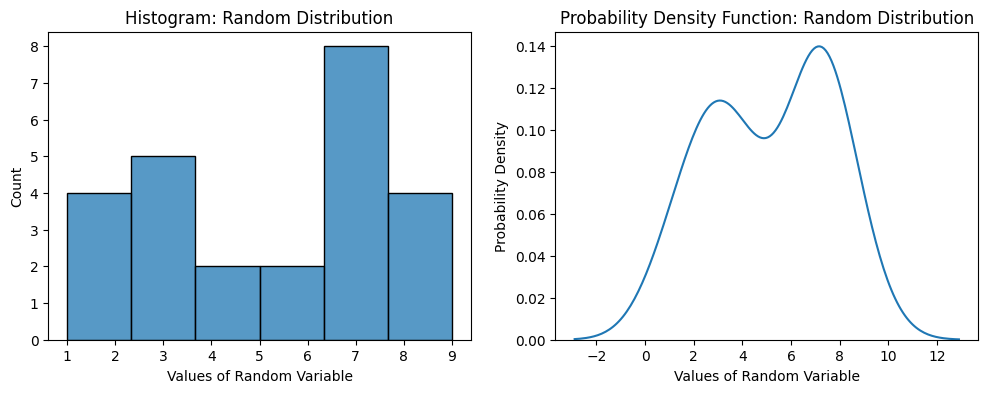

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data)
plt.title("Histogram: Random Distribution")
plt.xlabel("Values of Random Variable")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.kdeplot(data)
plt.title("Probability Density Function: Random Distribution")
plt.xlabel("Values of Random Variable")
plt.ylabel("Probability Density")

plt.show()

In [32]:
def get_sample_std(sample):
    """
    Function to compute sample standard deviation.
    """
    return np.std(sample, ddof=1).item()

In [33]:
sample_sds = bootstrapping(data, get_sample_std)
sample_sds[:5]

[2.5377155080899043,
 2.3825756371344577,
 2.254624876411447,
 2.0428737928059415,
 2.217355782608345]

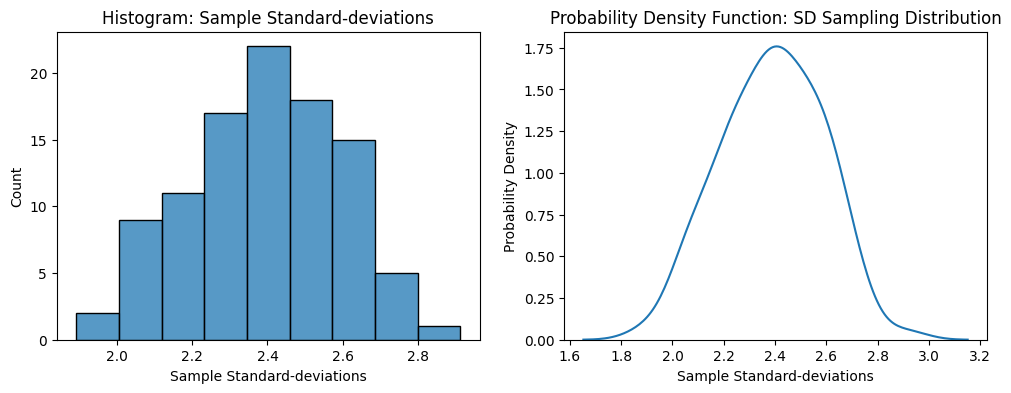

In [34]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(sample_sds)
plt.title("Histogram: Sample Standard-deviations")
plt.xlabel("Sample Standard-deviations")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.kdeplot(sample_sds)
plt.title("Probability Density Function: SD Sampling Distribution")
plt.xlabel("Sample Standard-deviations")
plt.ylabel("Probability Density")

plt.show()

In [35]:
x1 = np.percentile(sample_sds, 2.5).round(6).item()
x2 = np.percentile(sample_sds, 97.5).round(6).item()

print(f"There is 95% chance that Population Standard Deviation lies in between the range:")
x1, x2

There is 95% chance that Population Standard Deviation lies in between the range:


(2.045196, 2.724023)

### 3.4 Exercises

#### Exercise #1

The mean height of a sample of 100 adults was found to be 65 inches, with a standard deviation of 2.5 inches.  
Compute population mean with 95% confidence interval.

##### Solution

In [36]:
n = 100  # Sample size
x_bar = 65  # Sample mean
s = 2.5  # Sample Standard deviation
confidence = 0.95  # 95%
# Find x1 and x2

In [37]:
se = s / np.sqrt(n)
se.round(6).item()

0.25

In [38]:
z1 = sp.stats.norm.ppf(0.025)
z2 = sp.stats.norm.ppf(0.975)

z1.round(6).item(), z2.round(6).item()

(-1.959964, 1.959964)

In [39]:
# Find P(x1) = 2.5%
x1 = x_bar + (z1 * se)

# Find P(x2) = 97.5%
x2 = x_bar + (z2 * se)

x1.round(6).item(), x2.round(6).item()

(64.510009, 65.489991)

or

In [40]:
x1, x2 = sp.stats.norm.interval(confidence, loc=x_bar, scale=se)
x1.round(6).item(), x2.round(6).item()

(64.510009, 65.489991)

We can be 95% confident that the population mean can fall in between the range [64.51, 65.49].

#### Exercise #2

The sample mean recovery time of 100 patients after taking a drug was seen to be 10.5 days with a standard deviation of 2 days.  
Find the 95% confidence interval of the true mean.

##### Solution

In [41]:
n = 100
x_bar = 10.5
s = 2

confidence = 0.95  # 95%

In [42]:
se = s / np.sqrt(n)
se.round(6).item()

0.2

In [43]:
z1 = sp.stats.norm.ppf(0.025)
z2 = sp.stats.norm.ppf(0.975)

z1.round(6).item(), z2.round(6).item()

(-1.959964, 1.959964)

In [44]:
# Find P(x1) = 2.5%
x1 = x_bar + (z1 * se)

# Find P(x2) = 97.5%
x2 = x_bar + (z2 * se)

x1.round(6).item(), x2.round(6).item()

(10.108007, 10.891993)

or

In [45]:
x1, x2 = sp.stats.norm.interval(confidence, loc=x_bar, scale=se)
x1.round(6).item(), x2.round(6).item()

(10.108007, 10.891993)

#### Exercise #3

From a sample of 80 endangered birds, the average wingspan was found to be 45 cm, with a population standard deviation of 10 cm.  
What is the correct confidence interval of the mean wingspan of the entire population with 90% confidence.

##### Solution

In [46]:
n = 80
x_bar = 45
s = 10
confidence = 0.9  # 90%

In [47]:
se = s / np.sqrt(n)
se.round(6).item()

1.118034

In [48]:
z1 = sp.stats.norm.ppf(0.05)
z2 = sp.stats.norm.ppf(0.95)

z1.round(6).item(), z2.round(6).item()

(-1.644854, 1.644854)

In [49]:
# Find P(x1) = 5%
x1 = x_bar + (z1 * se)

# Find P(x2) = 95%
x2 = x_bar + (z2 * se)

x1.round(6).item(), x2.round(6).item()

(43.160998, 46.839002)

or

In [50]:
x1, x2 = sp.stats.norm.interval(confidence, loc=x_bar, scale=se)
x1.round(6).item(), x2.round(6).item()

(43.160998, 46.839002)

#### Exercise #4

In a software project, the team estimates bug resolution time at an average of 6 hours with a standard deviation of 2 hours.  
To estimate the mean resolution time with 99% confidence, the project manager samples 25 resolved bugs.  
What is the correct confidence interval?

##### Solution

In [51]:
x_bar = 6
s = 2
n = 25
confidence = 0.99

In [52]:
se = s / np.sqrt(n)
se.round(6).item()

0.4

In [53]:
x1, x2 = sp.stats.norm.interval(confidence, loc=x_bar, scale=se)
x1.round(6).item(), x2.round(6).item()

(4.969668, 7.030332)